##### Disciplina: Processamento de Imagens
##### Professor: Felipe Viel
##### Autores: Diogo Henrique Ribicki, João Victor da Silva, Pedro Henrique de Paula Cordeiro

# Classificação de Imagens com Redes Neurais Convolucionais

Nesta atividade prática foi desenvolvido um modelo de Rede Neural Convolucional (CNN) para classificação de imagens do dataset Rock Paper Scissors. O objetivo é classificar imagens em três categorias: rock, paper e scissors.

A atividade segue uma pipeline de aprendizado supervisionado, composta por coleta e preparação dos dados, aplicação de ruído, pré-processamento, treinamento da CNN e avaliação dos resultados.

## Descrição da tarefa

A tarefa desenvolvida é um problema de classificação de imagens. Cada imagem representa uma mão fazendo um dos três gestos possíveis: pedra, papel ou tesoura. A entrada do modelo é uma imagem RGB e a saída é uma das três classes disponíveis.

Como se trata de aprendizado supervisionado, cada imagem possui um rótulo associado, permitindo que a rede aprenda a relação entre os pixels da imagem e sua respectiva classe.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Correção da versão da lib
!pip uninstall -y tensorflow-datasets tensorflow-metadata protobuf

!pip install -q --no-cache-dir --force-reinstall \
  "protobuf==5.29.6" \
  "tensorflow-metadata==1.16.1" \
  "tensorflow-datasets==4.9.9"

In [21]:
# Carregando o dataset Rock Paper Scissors
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names

print("Classes:", class_names)
print("Quantidade de imagens de treino:", ds_info.splits['train'].num_examples)
print("Quantidade de imagens de teste:", ds_info.splits['test'].num_examples)

Classes: ['rock', 'paper', 'scissors']
Quantidade de imagens de treino: 2520
Quantidade de imagens de teste: 372


In [22]:
# Ajustes no tamanho das imagens e separação das imagens para treinamento e testes
IMG_SIZE = 96

def dataset_to_numpy(dataset, max_images=None):
    images = []
    labels = []

    for i, (image, label) in enumerate(tfds.as_numpy(dataset)):
        if max_images is not None and i >= max_images:
            break

        # Redimensiona a imagem para reduzir custo computacional
        image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        images.append(image_resized)
        labels.append(label)

    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int32)


# Dimensionamento do dataset para uso no colab free
X_train_full, y_train_full = dataset_to_numpy(ds_train_raw, max_images=1800)
X_test, y_test = dataset_to_numpy(ds_test_raw, max_images=300)

print("Treino completo:", X_train_full.shape, y_train_full.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino completo: (1800, 96, 96, 3) (1800,)
Teste: (300, 96, 96, 3) (300,)


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (1440, 96, 96, 3) (1440,)
Validação: (360, 96, 96, 3) (360,)
Teste: (300, 96, 96, 3) (300,)


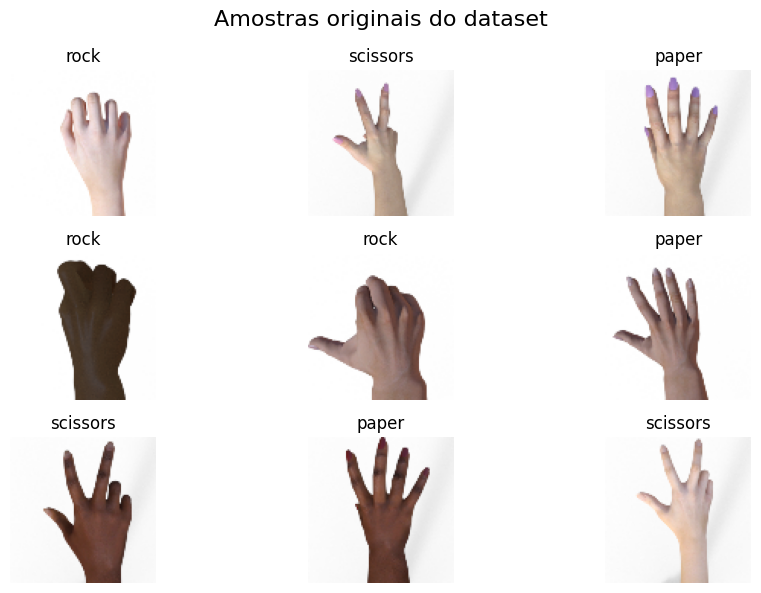

In [24]:
# Exibir imagens do dataset
def show_samples(images, labels, class_names, title="Amostras"):
    plt.figure(figsize=(10, 6))
    plt.suptitle(title, fontsize=16)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(X_train, y_train, class_names, title="Amostras originais do dataset")

## Aplicação de ruído e pré-processamento

Foi aplicado ruído do tipo Salt and Pepper nas imagens. Esse ruído altera pixels aleatórios para valores extremos, preto ou branco, simulando falhas ou interferências na imagem.

Para reduzir esse ruído, foi utilizado o filtro da mediana, uma técnica de filtragem espacial. Esse filtro substitui o valor de cada pixel pela mediana dos pixels vizinhos, sendo eficiente para remover ruídos pontuais sem borrar excessivamente as bordas.

Além disso, foi aplicada uma operação pontual de normalização, convertendo os valores dos pixels do intervalo [0, 255] para [0, 1]. Essa normalização facilita o treinamento da rede neural.

In [25]:
# Adiciona ruído as imagens
def add_salt_and_pepper_noise(image, amount=0.03, salt_vs_pepper=0.5):
    noisy = image.copy()
    h, w, c = noisy.shape

    num_pixels = h * w
    num_salt = int(amount * num_pixels * salt_vs_pepper)
    num_pepper = int(amount * num_pixels * (1.0 - salt_vs_pepper))

    # Salt: pixels brancos
    coords_salt_y = np.random.randint(0, h, num_salt)
    coords_salt_x = np.random.randint(0, w, num_salt)
    noisy[coords_salt_y, coords_salt_x, :] = 255

    # Pepper: pixels pretos
    coords_pepper_y = np.random.randint(0, h, num_pepper)
    coords_pepper_x = np.random.randint(0, w, num_pepper)
    noisy[coords_pepper_y, coords_pepper_x, :] = 0

    return noisy


def apply_noise_to_dataset(images, amount=0.03):
    noisy_images = []

    for img in images:
        noisy_img = add_salt_and_pepper_noise(img, amount=amount)
        noisy_images.append(noisy_img)

    return np.array(noisy_images, dtype=np.uint8)


X_train_noisy = apply_noise_to_dataset(X_train, amount=0.03)
X_val_noisy = apply_noise_to_dataset(X_val, amount=0.03)
X_test_noisy = apply_noise_to_dataset(X_test, amount=0.03)

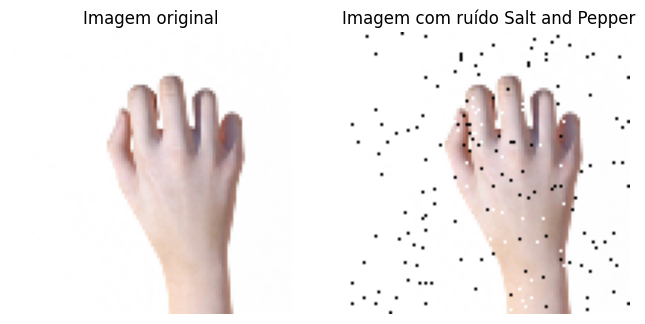

In [29]:
# Visualização do rúido
idx = 0

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_train[idx])
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train_noisy[idx])
plt.title("Imagem com ruído Salt and Pepper")
plt.axis("off")

plt.show()

In [30]:
# Retirada do rúido utilizando filtragem de mediana do cv2
def apply_median_filter(image, kernel_size=3):
    return cv2.medianBlur(image, kernel_size)


def apply_median_filter_to_dataset(images, kernel_size=3):
    filtered_images = []

    for img in images:
        filtered_img = apply_median_filter(img, kernel_size)
        filtered_images.append(filtered_img)

    return np.array(filtered_images, dtype=np.uint8)


X_train_filtered = apply_median_filter_to_dataset(X_train_noisy, kernel_size=3)
X_val_filtered = apply_median_filter_to_dataset(X_val_noisy, kernel_size=3)
X_test_filtered = apply_median_filter_to_dataset(X_test_noisy, kernel_size=3)

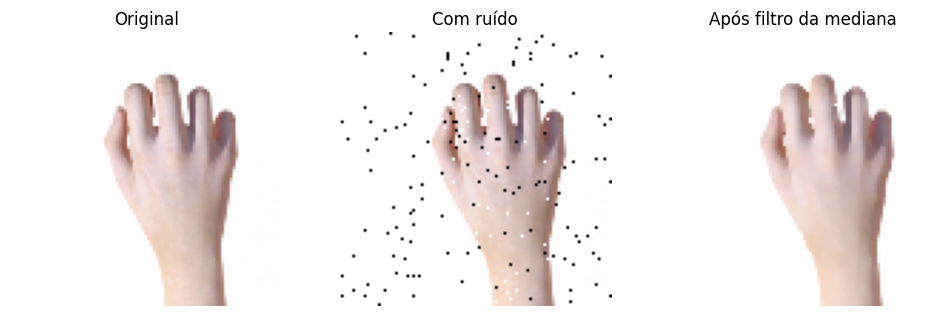

In [31]:
# Visualização das imagens antes e depois do pre processamento
idx = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_train[idx])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(X_train_noisy[idx])
plt.title("Com ruído")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(X_train_filtered[idx])
plt.title("Após filtro da mediana")
plt.axis("off")

plt.show()

In [32]:
X_train_processed = X_train_filtered.astype("float32") / 255.0
X_val_processed = X_val_filtered.astype("float32") / 255.0
X_test_processed = X_test_filtered.astype("float32") / 255.0

print("Valor mínimo treino:", X_train_processed.min())
print("Valor máximo treino:", X_train_processed.max())

Valor mínimo treino: 0.0
Valor máximo treino: 1.0


## Rede Neural Convolucional - CNN

A arquitetura utilizada é composta por camadas convolucionais, camadas de pooling, uma camada Flatten e camadas densas ao final.

As camadas convolucionais são responsáveis por extrair características locais das imagens, como bordas, formas e padrões visuais. As camadas de pooling reduzem a dimensionalidade dos mapas de características, tornando o processamento mais eficiente. Ao final, a camada densa com ativação Softmax realiza a classificação entre as três classes.

In [35]:
# Modelo 1
tf.random.set_seed(42)
np.random.seed(42)

model = models.Sequential([
    # Primeira etapa convolucional
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    # Segunda etapa convolucional
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Terceira etapa convolucional
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Transformação dos mapas de características em vetor
    layers.Flatten(),

    # Camada densa para decisão
    layers.Dense(128, activation='relu'),

    # Camada de saída: 3 classes
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,163 (6.61 MB)

 Trainable params: 1,732,163 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Treinamento 1
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_processed,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_processed, y_val),
    callbacks=callbacks
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 632ms/step - accuracy: 0.7139 - loss: 0.6406 - val_accuracy: 0.9472 - val_loss: 0.2223
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 662ms/step - accuracy: 0.9910 - loss: 0.0517 - val_accuracy: 0.9889 - val_loss: 0.0382
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 640ms/step - accuracy: 0.9972 - loss: 0.0129 - val_accuracy: 0.9972 - val_loss: 0.0056
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 691ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 696ms/step - accuracy: 1.0000 - loss: 4.1615e-04 - val_accuracy: 1.0000 - val_loss: 7.0542e-04
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 670ms/step - accuracy: 1.0000 - loss: 2.6590e-04 - val_accuracy: 1.0000 - val_loss: 4.6129e-04
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 784ms/step - accuracy: 1.0000 - loss: 1.9433e-04 - val_accuracy: 1.0000 - val_loss: 3.4759e-04
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 739ms/step - accuracy: 1.0000 -

In [39]:
# Loss e Acurácia do modelo
test_loss, test_accuracy = model.evaluate(X_test_processed, y_test)

print(f"Loss no teste: {test_loss:.4f}")
print(f"Acurácia no teste: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.8567 - loss: 1.0719
Loss no teste: 1.0719
Acurácia no teste: 0.8567


In [40]:
# Outras métricas da classificação
y_pred_probs = model.predict(X_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step
              precision    recall  f1-score   support

        rock       0.90      0.78      0.84       101
       paper       0.82      0.98      0.89       103
    scissors       0.87      0.80      0.83        96

    accuracy                           0.86       300
   macro avg       0.86      0.85      0.85       300
weighted avg       0.86      0.86      0.85       300



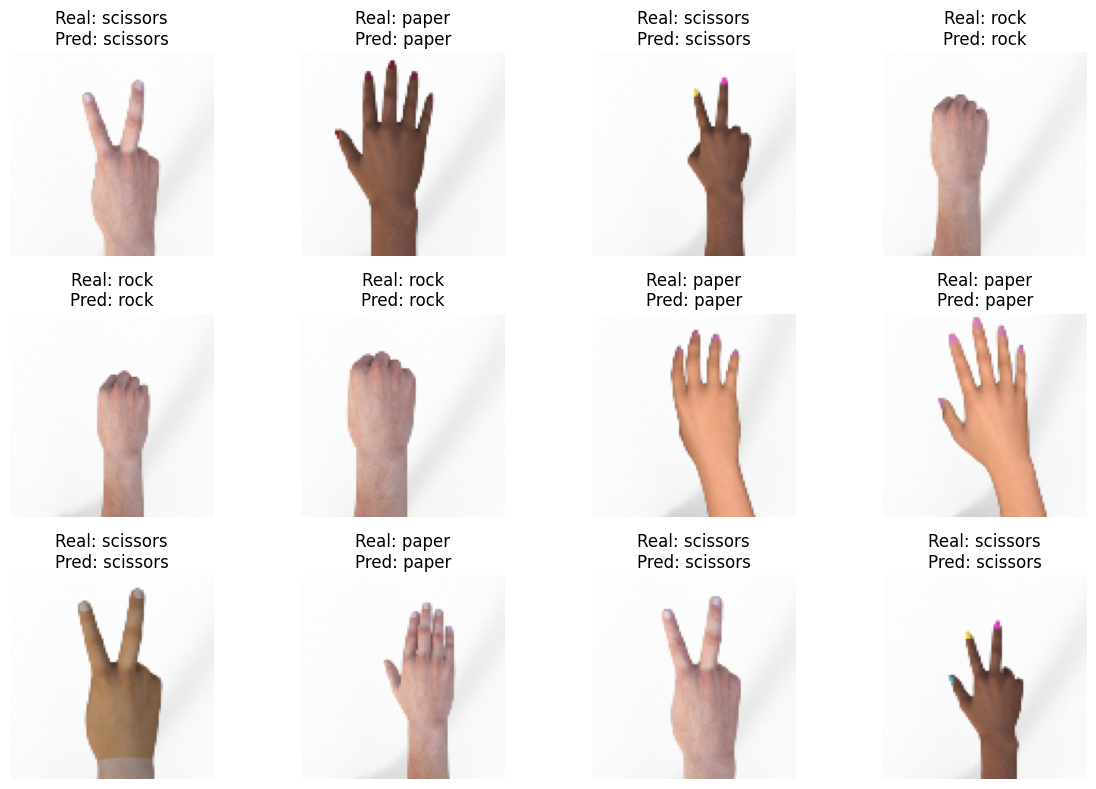

In [42]:
# Comparação entre as classificações das imagens real x modelo treinado
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])

    real = class_names[y_test[i]]
    pred = class_names[y_pred[i]]

    if real == pred:
        title = f"Real: {real}\nPred: {pred}"
    else:
        title = f"Real: {real}\nPred: {pred} ERRO"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()



## Comparação entre modelos

Foram avaliadas duas arquiteturas de CNN. O primeiro modelo utilizou camadas convolucionais e pooling, mas sem padding e sem dropout. Ele obteve acurácia de 88,33% no conjunto de teste.

O segundo modelo adicionou padding='same' nas convoluções e Dropout antes da camada de saída. Com essas modificações, a acurácia no teste aumentou para 95,00%, indicando melhor capacidade de generalização.

O padding ajudou a preservar informações nas bordas das imagens, enquanto o Dropout reduziu o risco de overfitting.

In [7]:
# Modelo 2
tf.random.set_seed(42)
np.random.seed(42)

model_v2 = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(3, activation='softmax')
])

model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,059 (9.36 MB)

 Trainable params: 2,453,059 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Treinamento 2
callbacks_v2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
]

history_v2 = model_v2.fit(
    X_train_processed,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_processed, y_val),
    callbacks=callbacks_v2
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 732ms/step - accuracy: 0.5715 - loss: 0.9216 - val_accuracy: 0.8917 - val_loss: 0.3258
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 766ms/step - accuracy: 0.9111 - loss: 0.2503 - val_accuracy: 0.9806 - val_loss: 0.0970
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 719ms/step - accuracy: 0.9750 - loss: 0.0950 - val_accuracy: 0.9750 - val_loss: 0.0892
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 722ms/step - accuracy: 0.9840 - loss: 0.0617 - val_accuracy: 0.9944 - val_loss: 0.0266
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 811ms/step - accuracy: 0.9931 - loss: 0.0262 - val_accuracy: 0.9917 - val_loss: 0.0225
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 762ms/step - accuracy: 0.9931 - loss: 0.0220 - val_accuracy: 0.9944 - val_loss: 0.0096
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 751ms/step - accuracy: 0.9944 - loss: 0.0144 - val_accuracy: 0.9972 - val_loss: 0.0075
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 714ms/step - accuracy: 0.9972 - loss: 0.0155 - val_accu

In [19]:
# Loss e Acurácia do modelo
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test_processed, y_test)

print(f"Loss no teste - Modelo 2: {test_loss_v2:.4f}")
print(f"Acurácia no teste - Modelo 2: {test_accuracy_v2:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.9500 - loss: 0.1553
Loss no teste - Modelo 2: 0.1553
Acurácia no teste - Modelo 2: 0.9500


In [20]:
# Outras métricas da classificação
y_pred_probs_v2 = model_v2.predict(X_test_processed)
y_pred_v2 = np.argmax(y_pred_probs_v2, axis=1)

print(classification_report(
    y_test,
    y_pred_v2,
    target_names=class_names
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step
              precision    recall  f1-score   support

        rock       1.00      0.92      0.96       101
       paper       0.90      1.00      0.95       103
    scissors       0.96      0.93      0.94        96

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



## Conclusão

A CNN desenvolvida apresentou bom desempenho na classificação das imagens do dataset Rock Paper Scissors. O primeiro modelo obteve acurácia de 88,33% no teste, enquanto o segundo modelo, com padding e dropout, alcançou 95,00%.

Os resultados mostram que as escolhas de arquitetura influenciam diretamente a capacidade de generalização da rede. O uso de padding permitiu preservar melhor as informações espaciais das imagens, e o uso de dropout contribuiu para reduzir overfitting.

Assim, a atividade demonstrou na prática o funcionamento de uma pipeline de classificação de imagens com redes neurais convolucionais, incluindo ruído, pré-processamento, treinamento, avaliação e melhoria do modelo.

In [47]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Descrição": [
        "CNN sem padding e sem dropout",
        "CNN com padding='same' e dropout"
    ],
    "Acurácia no teste": [0.8567, 0.9500],
    "Loss no teste": [1.0719, 0.1553],
    "Macro F1-score": [0.85, 0.95]
})

resultados

,Modelo,Descrição,Acurácia no teste,Loss no teste,Macro F1-score
0,Modelo 1,CNN sem padding e sem dropout,0.8567,1.0719,0.85
1,Modelo 2,CNN com padding='same' e dropout,0.9500,0.1553,0.95


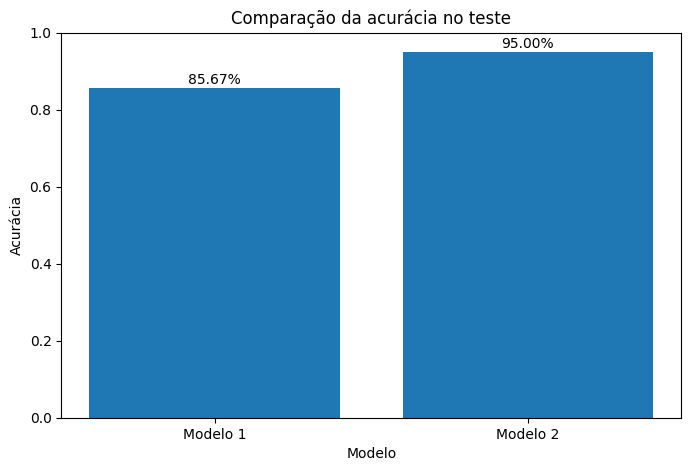

In [48]:
plt.figure(figsize=(8, 5))
plt.bar(resultados["Modelo"], resultados["Acurácia no teste"])
plt.title("Comparação da acurácia no teste")
plt.xlabel("Modelo")
plt.ylabel("Acurácia")
plt.ylim(0, 1)

for i, value in enumerate(resultados["Acurácia no teste"]):
    plt.text(i, value + 0.01, f"{value:.2%}", ha="center")

plt.show()